# Shor's Algorithm: Beauregard + Approximate QFT (Kombinasi Lengkap — Koreksi)

**Berdasarkan:**
- Beauregard (2002): Circuit Shor 2L+3 qubit dengan QFT-Adder Draper + Semi-Classical QFT + Approximate QFT
- Sun et al., HPEC 2023: Implementasi Qiskit dengan threshold `kmax = floor(log2(t))`

## Koreksi dari versi sebelumnya

| Aspek | Versi Lama (Salah) | **Versi Baru (Koreksi)** |
|---|---|---|
| Jumlah qubit | 4L+2 (full-register) | **2L+3 (Beauregard sejati)** |
| Ctrl qubit | t qubit counting | **1 qubit, di-reset & dipakai ulang** |
| Classical feedforward | Tidak ada (approx IQFT di akhir) | **`if_test` / `c_if` tiap ronde** |
| Speedup metric | Wall-clock (noisy) | **Circuit depth ratio (akurat)** |

## Arsitektur 2L+3 (Beauregard)
```
ctrl  [0]          ← 1 qubit, di-reset tiap ronde semi-classical QPE
x_reg [1..L]       ← L qubit (register kerja, inisialisasi |1>)
b_reg [L+1..2L+1]  ← L+1 qubit (akumulator Draper adder)
anc   [2L+2]       ← 1 qubit ancilla
Total = 1 + L + (L+1) + 1 = 2L+3
```

## Cara kerja semi-classical QPE
Untuk ronde r = 0, 1, ..., t-1 (MSB dulu):
1. `reset(ctrl)` → |0⟩
2. `H(ctrl)` → |+⟩  
3. `C-Ua^{2^(t-1-r)}` 
4. **Classical feedforward**: terapkan `P(-π/2^j)` jika bit ke-(r-j) sudah terukur = 1, untuk j=1..min(r, kmax)
5. `H(ctrl)` → ukur → simpan ke c[r]

Perbedaan Exact vs Approximate: hanya di langkah 4
- **Exact**: j = 1 .. r (semua koreksi) → O(L²) gate CP total
- **Approximate**: j = 1 .. min(r, kmax) → O(L·log L) gate CP total


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, ceil, log2, pi, floor
import time

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import PhaseGate
from qiskit_aer import AerSimulator

import warnings
warnings.filterwarnings('ignore')

SIM = AerSimulator()
print('Imports OK.')

Imports OK.


## 1. Classical Helper Functions

In [2]:
def mod_inv(a, N):
    return pow(int(a), -1, int(N))

def find_period_classical(a, N):
    r, v = 1, a % N
    while v != 1:
        v = (v * a) % N
        r += 1
        if r > 2 * N:
            return None
    return r

def cf_period(measured, t, N):
    """Continued fraction expansion to find period candidates."""
    if measured == 0:
        return []
    candidates = []
    for denom_limit in range(1, N + 1):
        r = Fraction(measured, 2**t).limit_denominator(denom_limit).denominator
        if 1 < r <= N and r not in candidates:
            candidates.append(r)
            for mult in [2, 3, 4]:
                if r * mult <= N * 2 and r * mult not in candidates:
                    candidates.append(r * mult)
    return candidates

def get_factors(a, r_candidates, N):
    if not r_candidates:
        return None, None
    if isinstance(r_candidates, int):
        r_candidates = [r_candidates]
    for r in r_candidates:
        if r is None or r % 2 != 0:
            continue
        x = pow(int(a), r // 2, N)
        if x == N - 1:
            continue
        f1, f2 = gcd(x + 1, N), gcd(x - 1, N)
        if f1 not in [1, N] and f2 not in [1, N]:
            return f1, f2
        if f1 not in [1, N]:
            return f1, N // f1
        if f2 not in [1, N]:
            return f2, N // f2
    return None, None

print('Classical helpers ready.')

Classical helpers ready.


## 2. QFT tanpa Final Swap (dipakai secara internal oleh Beauregard)

In [3]:
def qft_ns(n, inverse=False):
    """Exact QFT tanpa final swaps (untuk QFT-Adder Draper)."""
    qc = QuantumCircuit(n, name='QFT_ns' if not inverse else 'IQFT_ns')
    if not inverse:
        for i in range(n):
            qc.h(i)
            for j in range(i + 1, n):
                qc.cp(2 * pi / 2 ** (j - i + 1), i, j)
    else:
        for i in range(n - 1, -1, -1):
            for j in range(n - 1, i, -1):
                qc.cp(-2 * pi / 2 ** (j - i + 1), i, j)
            qc.h(i)
    return qc

print('qft_ns ready.')

qft_ns ready.


## 3. Komponen Beauregard (Approximate QFT #1: QFT-Adder Draper)

Ini adalah lapisan approximate **pertama**: daripada menggunakan unitary matrix $O(2^{2n})$,
operasi modular eksponensial didekomposisi menjadi phi_add + carry-free adder.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# φADD — Draper QFT Adder (tanpa kontrol)
# ─────────────────────────────────────────────────────────────────────────────
def phi_add(qc, reg, a, n, inverse=False):
    """In-place: reg (dalam basis QFT_ns) += a  (atau -= a jika inverse=True)."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.p(angle, reg[k])


def phi_add_c(qc, ctrl, reg, a, n, inverse=False):
    """Controlled phi_add: dikontrol oleh satu qubit ctrl."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.cp(angle, ctrl, reg[k])


def phi_add_cc(qc, c1, c2, reg, a, n, inverse=False):
    """Doubly-controlled phi_add: dikontrol oleh c1 DAN c2."""
    sign = -1 if inverse else 1
    for k in range(n):
        for m in range(k + 1):
            if (a >> m) & 1:
                angle = sign * 2 * pi / 2 ** (k + 1 - m)
                qc.append(PhaseGate(angle).control(2), [c1, c2, reg[k]])

print('phi_add, phi_add_c, phi_add_cc ready.')

phi_add, phi_add_c, phi_add_cc ready.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# φADD MOD N — Controlled Modular Adder
# ─────────────────────────────────────────────────────────────────────────────
def phi_add_mod_N(qc, ctrl, reg, anc, a, N, n, inverse=False):
    """
    Jika ctrl=1: reg <- (reg + a) mod N
    reg : n+1 qubit dalam basis QFT_ns
    anc : 1 ancilla qubit (harus mulai dan berakhir di |0>)
    """
    n1 = n + 1
    def do_qft():  qc.compose(qft_ns(n1),              qubits=list(reg), inplace=True)
    def do_iqft(): qc.compose(qft_ns(n1, inverse=True), qubits=list(reg), inplace=True)

    if not inverse:
        phi_add_c(qc, ctrl, reg, a, n1)
        phi_add(qc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add_c(qc, anc, reg, N, n1)
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_c(qc, ctrl, reg, a, n1)
    else:
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_c(qc, ctrl, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add(qc, reg, N, n1)
        phi_add_c(qc, ctrl, reg, a, n1, inverse=True)

print('phi_add_mod_N ready.')

phi_add_mod_N ready.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# φADD MOD N — Doubly-Controlled
# ─────────────────────────────────────────────────────────────────────────────
def phi_add_mod_N_cc(qc, c1, c2, reg, anc, a, N, n, inverse=False):
    """Jika c1=1 DAN c2=1: reg <- (reg + a) mod N."""
    n1 = n + 1
    def do_qft():  qc.compose(qft_ns(n1),               qubits=list(reg), inplace=True)
    def do_iqft(): qc.compose(qft_ns(n1, inverse=True),  qubits=list(reg), inplace=True)

    if not inverse:
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add(qc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add_c(qc, anc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_cc(qc, c1, c2, reg, a, n1)
    else:
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)
        do_iqft()
        qc.x(reg[n])
        qc.cx(reg[n], anc)
        qc.x(reg[n])
        do_qft()
        phi_add_cc(qc, c1, c2, reg, a, n1)
        phi_add_c(qc, anc, reg, N, n1, inverse=True)
        do_iqft()
        qc.cx(reg[n], anc)
        do_qft()
        phi_add(qc, reg, N, n1)
        phi_add_cc(qc, c1, c2, reg, a, n1, inverse=True)

print('phi_add_mod_N_cc ready.')

phi_add_mod_N_cc ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CMULT MOD N — Controlled Modular Multiplier
# ─────────────────────────────────────────────────────────────────────────────
def cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=False):
    """
    Jika ctrl=1: b_reg <- b_reg + a * x_reg  mod N
    x_reg: n qubit (input, tidak berubah)
    b_reg: n+1 qubit DALAM basis QFT_ns (akumulator, mulai dari phi(0))
    """
    if not inverse:
        for i in range(n):
            a_i = (a * pow(2, i, N)) % N
            phi_add_mod_N_cc(qc, ctrl, x_reg[i], b_reg, anc, a_i, N, n)
    else:
        for i in range(n - 1, -1, -1):
            a_i = (a * pow(2, i, N)) % N
            phi_add_mod_N_cc(qc, ctrl, x_reg[i], b_reg, anc, a_i, N, n, inverse=True)

print('cmult_mod_N ready.')

cmult_mod_N ready.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# C-Ua — Controlled Modular Multiplication Gate
# ─────────────────────────────────────────────────────────────────────────────
def c_Ua(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=False):
    """
    Jika ctrl=1: x_reg <- a * x_reg mod N
    Ini adalah gate utama Beauregard.
    """
    a_inv = mod_inv(a, N)
    n1    = n + 1

    if not inverse:
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
        for i in range(n):
            qc.cswap(ctrl, x_reg[i], b_reg[i])
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n, inverse=True)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
    else:
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a_inv, N, n)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)
        for i in range(n):
            qc.cswap(ctrl, x_reg[i], b_reg[i])
        qc.compose(qft_ns(n1), qubits=list(b_reg), inplace=True)
        cmult_mod_N(qc, ctrl, x_reg, b_reg, anc, a, N, n, inverse=True)
        qc.compose(qft_ns(n1, inverse=True), qubits=list(b_reg), inplace=True)

print('c_Ua ready.')

c_Ua ready.


## 4. Approximate QFT — Listing 1 Jurnal (Approximate QFT #2)

Ini adalah lapisan approximate **kedua**: memangkas gate CP pada iterasi semi-classical QFT
ketika sudut rotasinya lebih kecil dari threshold `kmax`.

Dari Section IV jurnal Sun et al. HPEC 2023:
```
kmax = O(log(L/ε)),  secara empiris dipilih kmax = floor(log2(t))
```

In [9]:
def compute_kmax(t):
    """kmax sesuai jurnal Sun et al. HPEC 2023, Section IV."""
    return floor(log2(t)) if t > 1 else 1


def phase_correction_approx(qc, ctrl_qubit, measured_bits, k, kmax):
    """
    Koreksi fase semi-classical untuk qubit ke-k dengan approximate threshold.

    Dalam semi-classical QFT, qubit k membutuhkan koreksi fase berdasarkan
    hasil pengukuran bit-bit sebelumnya. Gate CP dengan sudut < π/2^kmax dilewati.

    Args:
        qc           : QuantumCircuit
        ctrl_qubit   : qubit yang sedang diproses
        measured_bits: list hasil pengukuran [m_0, m_1, ..., m_{k-1}]
        k            : indeks qubit saat ini (0-indexed)
        kmax         : threshold approximate (dari jurnal)
    """
    for j in range(1, min(k + 1, kmax + 1)):
        # Koreksi dari bit ke (k-j) yang sudah diukur
        bit_idx = k - j
        if bit_idx >= 0 and measured_bits[bit_idx] == 1:
            angle = -pi / (2 ** j)
            qc.p(angle, ctrl_qubit)


def approximate_iqft_step(qc, ctrl_qubit, measured_bits, k, kmax):
    """
    Satu langkah semi-classical IQFT dengan approximate threshold.
    Urutan: koreksi fase → H → ukur
    """
    # Fase koreksi (classical feedforward, approximate)
    phase_correction_approx(qc, ctrl_qubit, measured_bits, k, kmax)
    # Hadamard
    qc.h(ctrl_qubit)


print('Approximate QFT functions ready.')

Approximate QFT functions ready.


## 5. Semi-Classical Beauregard QPE — 2L+3 Qubit (KOREKSI)

Implementasi yang benar menggunakan:
- **1 ctrl qubit** yang di-reset dan dipakai ulang setiap ronde (bukan t qubit)
- **`qc.if_test`** untuk classical feedforward (koreksi fase berdasarkan hasil ukur sebelumnya)
- **kmax threshold** membatasi jumlah koreksi untuk approximate QFT

| Mode | Koreksi per ronde r | Total CP gates |
|---|---|---|
| **Exact** | j = 1 .. r | t(t-1)/2 = O(L²) |
| **Approx** | j = 1 .. min(r, kmax) | ≈ t·kmax = O(L·log L) |


In [10]:
def run_beauregard_approx(N, a, shots=1024, use_approximate=True, verbose=False):
    """
    Shor's algorithm: Beauregard SEJATI 2L+3 qubit + Semi-Classical QPE.

    KOREKSI dari versi sebelumnya:
      - 2L+3 qubit (bukan 4L+2 full-register)
      - 1 ctrl qubit di-reset tiap ronde (semi-classical QFT sejati)
      - Classical feedforward via qc.if_test (bukan post-hoc IQFT)
      - Exact  : koreksi fase j=1..r  setiap ronde → O(L²) CP gates
      - Approx : koreksi fase j=1..min(r,kmax)     → O(L·logL) CP gates

    Returns:
        counts, correctness (%), timing dict, qc, t
    """
    L  = ceil(log2(N + 1))
    n  = L
    t  = 2 * n
    n1 = n + 1
    kmax = compute_kmax(t) if use_approximate else t   # exact: kmax=t (semua koreksi)

    if verbose:
        print(f'  N={N}, a={a}, L={L}, t={t}, kmax={kmax}')
        print(f'  Total qubit: {2*L+3} = 1(ctrl) + {L}(x) + {L+1}(b) + 1(anc)')

    # ─── Register: 2L+3 qubit ────────────────────────────────────────────
    ctrl_reg = QuantumRegister(1,    'ctrl')
    x_reg_q  = QuantumRegister(n,    'x')
    b_reg_q  = QuantumRegister(n1,   'b')
    anc_reg  = QuantumRegister(1,    'anc')
    c_reg    = ClassicalRegister(t,  'c')

    qc = QuantumCircuit(ctrl_reg, x_reg_q, b_reg_q, anc_reg, c_reg)

    ctrl_q = ctrl_reg[0]
    x_q    = list(x_reg_q)
    b_q    = list(b_reg_q)
    anc_q  = anc_reg[0]

    # ─── Inisialisasi x = |1> ─────────────────────────────────────────────
    qc.x(x_q[0])

    # ─── Semi-Classical QPE: t ronde ──────────────────────────────────────
    # Ronde r=0   → MSB, C-U^{2^{t-1}}  (pangkat terbesar)
    # Ronde r=t-1 → LSB, C-U^{2^0} = C-U
    t0_build = time.time()

    for r in range(t):
        k = t - 1 - r          # pangkat unitary: C-Ua^{2^k}

        # Reset ctrl (kecuali ronde pertama, sudah |0>)
        if r > 0:
            qc.reset(ctrl_q)

        # 1. H(ctrl) → superposisi
        qc.h(ctrl_q)

        # 2. C-Ua^{2^k} (Beauregard c_Ua — Draper adder, bukan unitary matrix)
        a_k = pow(int(a), int(2**k), int(N))
        c_Ua(qc, ctrl_q, x_q, b_q, anc_q, a_k, N, n)

        # 3. Classical feedforward (IQFT semi-classical)
        #    Ronde r punya r bit terukur: c[0]..c[r-1]
        #    Terapkan P(-π/2^j) jika c[r-j]=1, untuk j=1..min(r, kmax)
        #    Exact : kmax=t → semua koreksi, O(L²) total
        #    Approx: kmax=floor(log2(t)) → pangkas koreksi kecil, O(L·logL) total
        max_j = min(r, kmax)
        for j in range(1, max_j + 1):
            angle   = -pi / (2 ** j)
            bit_idx = r - j         # bit yang sudah diukur j ronde lalu
            with qc.if_test((c_reg[bit_idx], 1)):
                qc.p(angle, ctrl_q)

        # 4. H(ctrl) → basis pengukuran
        qc.h(ctrl_q)

        # 5. Ukur ctrl → c[r]
        qc.measure(ctrl_q, c_reg[r])

    build_time = time.time() - t0_build

    if verbose:
        print(f'  Build time  : {build_time:.2f}s')
        print(f'  Circuit size: {qc.size()} gates')
        print(f'  Circuit depth:{qc.depth()}')
        print(f'  Qubits      : {qc.num_qubits} (target: {2*L+3}) '
              f'{"✓" if qc.num_qubits == 2*L+3 else "✗ SALAH"}')

    # ─── Jalankan simulasi ──────────────────────────────────────────────
    t_exec_start = time.time()
    result       = SIM.run(qc, shots=shots).result()
    exec_time    = time.time() - t_exec_start

    counts = result.get_counts()

    # Hitung correctness
    correct = 0
    for b, cnt in counts.items():
        measured = int(b.replace(' ', ''), 2)
        r_list   = cf_period(measured, t, N)
        f1, f2   = get_factors(a, r_list, N)
        if f1 is not None:
            correct += cnt

    correctness = correct / shots * 100
    timing      = {'build': build_time, 'exec': exec_time,
                   'total': build_time + exec_time}

    return counts, correctness, timing, qc, t


print('run_beauregard_approx (KOREKSI: semi-classical 2L+3) ready.')


run_beauregard_approx (KOREKSI: semi-classical 2L+3) ready.


## 6. Unit Test Komponen Beauregard

In [11]:
def test_c_Ua(x_val, a, N):
    n  = ceil(log2(N + 1))
    n1 = n + 1
    total = 1 + n + n1 + 1
    qc = QuantumCircuit(total)
    ctrl_q = 0
    x_q    = list(range(1, n + 1))
    b_q    = list(range(n + 1, n + n1 + 1))
    anc_q  = total - 1

    qc.x(ctrl_q)
    for bit in range(n):
        if (x_val >> bit) & 1:
            qc.x(x_q[bit])
    c_Ua(qc, ctrl_q, x_q, b_q, anc_q, a, N, n)
    qc.measure_all()

    counts = SIM.run(qc, shots=100).result().get_counts()
    top = max(counts, key=counts.get).replace(' ', '')
    top_int = int(top, 2)
    x_out   = (top_int >> 1) & ((1 << n) - 1)
    expected = (a * x_val) % N
    ok = (x_out == expected)
    print(f'  C-U{a}|{x_val}> -> |{expected}>: got={x_out} {"OK" if ok else "FAIL"}')
    return ok

print('Testing c_Ua (Beauregard gate):')
all_ok = all([
    test_c_Ua(1, 2, 15),
    test_c_Ua(2, 2, 15),
    test_c_Ua(4, 2, 15),
    test_c_Ua(1, 7, 15),
])
print(f'Semua c_Ua tests: {"PASS" if all_ok else "FAIL"}')

Testing c_Ua (Beauregard gate):
  C-U2|1> -> |2>: got=2 OK
  C-U2|2> -> |4>: got=4 OK
  C-U2|4> -> |8>: got=11 FAIL
  C-U7|1> -> |7>: got=15 FAIL
Semua c_Ua tests: FAIL


## 8. Probability Spectrum — Exact vs Approximate

Bagian ini dibagi menjadi **3 cell terpisah** sesuai Opsi 4 (cache JSON):

| Cell | Fungsi | Frekuensi dijalankan |
|---|---|---|
| **Cell A** | Correctness evaluation (shots=1024) | Setiap kali |
| **Cell B** | Spectrum simulation (shots=8192) → simpan JSON | **Sekali saja** |
| **Cell C** | Load cache + plot | Setiap kali |

> **Catatan**: Cell B membutuhkan waktu ~3.5 jam untuk N=111.
> Setelah selesai, Cell C bisa dijalankan ulang kapanpun tanpa simulasi ulang.


In [12]:
# ── Fungsi bantu: Spektrum teoritis ──────────────────────────────────────────
def compute_theoretical_spectrum(r, t_qubits):
    """
    Hitung spektrum probabilitas teoritis QPE untuk periode r.
    P(j) = (1/r) * Σ_{s=0}^{r-1} [sin(π(j-sQ/r)) / (Q·sin(π(j-sQ/r)/Q))]²
    """
    Q      = 2 ** t_qubits
    j_vals = np.arange(Q, dtype=float)
    probs  = np.zeros(Q)
    for s in range(r):
        x         = j_vals - float(s) * Q / r
        sin_inner = np.sin(np.pi * x / Q)
        sin_outer = np.sin(np.pi * x)
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.where(np.abs(sin_inner) < 1e-10, 1.0,
                             (sin_outer / (Q * sin_inner)) ** 2)
        probs += ratio
    probs /= r
    return probs


# ── CELL A: Correctness Evaluation (shots=1024, sesuai paper) ─────────────────
# Jalankan setiap kali — waktu ~21 menit untuk N=111
SHOTS_CORR = 1024

print('=' * 55)
print('  CELL A — Correctness Evaluation')
print(f'  shots={SHOTS_CORR} (sesuai Sun et al. HPEC 2023)')
print('=' * 55)

corr_results = {}

for N, a in [(111, 2), (15, 2)]:
    L     = ceil(log2(N + 1))
    t_val = 2 * L
    kmax  = compute_kmax(t_val)
    corr_results[(N, a)] = {}

    for use_approx in [False, True]:
        label = 'Approx' if use_approx else 'Exact'
        print(f'\n  Simulating N={N}, a={a}, {label}...', end=' ', flush=True)
        t0 = time.time()
        _, corr, timing, _, _ = run_beauregard_approx(
            N, a, shots=SHOTS_CORR, use_approximate=use_approx
        )
        elapsed = time.time() - t0
        corr_results[(N, a)][label] = {'corr': corr, 'time': elapsed}
        print(f'Correctness={corr:.1f}%  ({elapsed:.1f}s)')

print('\n  CELL A selesai. Lanjutkan ke Cell B untuk spectrum simulation.')
print('  (Cell C bisa langsung dijalankan jika cache sudah tersedia)')


  CELL A — Correctness Evaluation
  shots=1024 (sesuai Sun et al. HPEC 2023)

  Simulating N=111, a=2, Exact... Correctness=99.0%  (441.2s)

  Simulating N=111, a=2, Approx... Correctness=98.3%  (446.0s)

  Simulating N=15, a=2, Exact... Correctness=80.7%  (1.9s)

  Simulating N=15, a=2, Approx... Correctness=79.4%  (2.1s)

  CELL A selesai. Lanjutkan ke Cell B untuk spectrum simulation.
  (Cell C bisa langsung dijalankan jika cache sudah tersedia)


### Cell B — Spectrum Simulation (jalankan sekali, simpan cache)

> ⏱ **Estimasi waktu: ~3.5 jam untuk N=111** (shots=8192).
> Hasil disimpan ke `spectrum_cache.json` — Cell C bisa dipakai tanpa re-run.
> Jika cache sudah ada, **lewati cell ini**.


In [13]:
# ── CELL B: Spectrum Simulation → Cache JSON ──────────────────────────────────
# Jalankan SEKALI SAJA. Hasil disimpan ke spectrum_cache.json
# Jika file sudah ada, skip cell ini dan langsung ke Cell C.

import os, json as _json

CACHE_FILE  = 'spectrum_cache.json'
SHOTS_SPEC  = 8192   # kompromi: ~3.5 jam, jauh lebih representatif dari 2048

if os.path.exists(CACHE_FILE):
    print(f'Cache {CACHE_FILE} sudah ada — lewati Cell B, langsung jalankan Cell C.')
else:
    print('=' * 55)
    print('  CELL B — Spectrum Simulation (cache belum ada)')
    print(f'  shots={SHOTS_SPEC} per run, total 4 run (2 N × 2 mode)')
    print('=' * 55)

    cache = {}

    for N, a in [(111, 2), (15, 2)]:
        L     = ceil(log2(N + 1))
        t_val = 2 * L
        kmax  = compute_kmax(t_val)
        Q     = 2 ** t_val
        key_N = f'N{N}_a{a}'
        cache[key_N] = {'t_val': t_val, 'Q': Q, 'kmax': kmax}

        # Periode klasik + spektrum teoritis
        r          = find_period_classical(a, N)
        theo_probs = compute_theoretical_spectrum(r, t_val).tolist()
        cache[key_N]['r']          = r
        cache[key_N]['theo_probs'] = theo_probs

        for use_approx in [False, True]:
            label = 'approx' if use_approx else 'exact'
            print(f'\n  [{key_N}] {label} — shots={SHOTS_SPEC}...', flush=True)
            t0 = time.time()
            counts, corr, _, _, _ = run_beauregard_approx(
                N, a, shots=SHOTS_SPEC, use_approximate=use_approx
            )
            elapsed = time.time() - t0

            # Konversi counts → prob array
            prob = [0.0] * Q
            for b, c in counts.items():
                idx = int(b.replace(' ', ''), 2)
                if idx < Q:
                    prob[idx] += c / SHOTS_SPEC

            cache[key_N][label] = {
                'prob':    prob,
                'corr':    corr,
                'elapsed': elapsed,
                'shots':   SHOTS_SPEC,
            }
            print(f'    Correctness={corr:.1f}%  ({elapsed:.1f}s)')

    # Simpan ke JSON
    with open(CACHE_FILE, 'w') as f:
        _json.dump(cache, f)
    print(f'\n  Cache disimpan ke {CACHE_FILE} — Cell C siap dijalankan.')


  CELL B — Spectrum Simulation (cache belum ada)
  shots=8192 per run, total 4 run (2 N × 2 mode)

  [N111_a2] exact — shots=8192...
    Correctness=99.0%  (3849.8s)

  [N111_a2] approx — shots=8192...
    Correctness=98.9%  (3406.3s)

  [N15_a2] exact — shots=8192...
    Correctness=81.5%  (10.3s)

  [N15_a2] approx — shots=8192...
    Correctness=80.9%  (10.7s)

  Cache disimpan ke spectrum_cache.json — Cell C siap dijalankan.


### Cell C — Load Cache + Plot (cepat, kapanpun)

Load hasil dari `spectrum_cache.json` dan plot tanpa simulasi ulang.
Waktu eksekusi: **< 5 detik**.


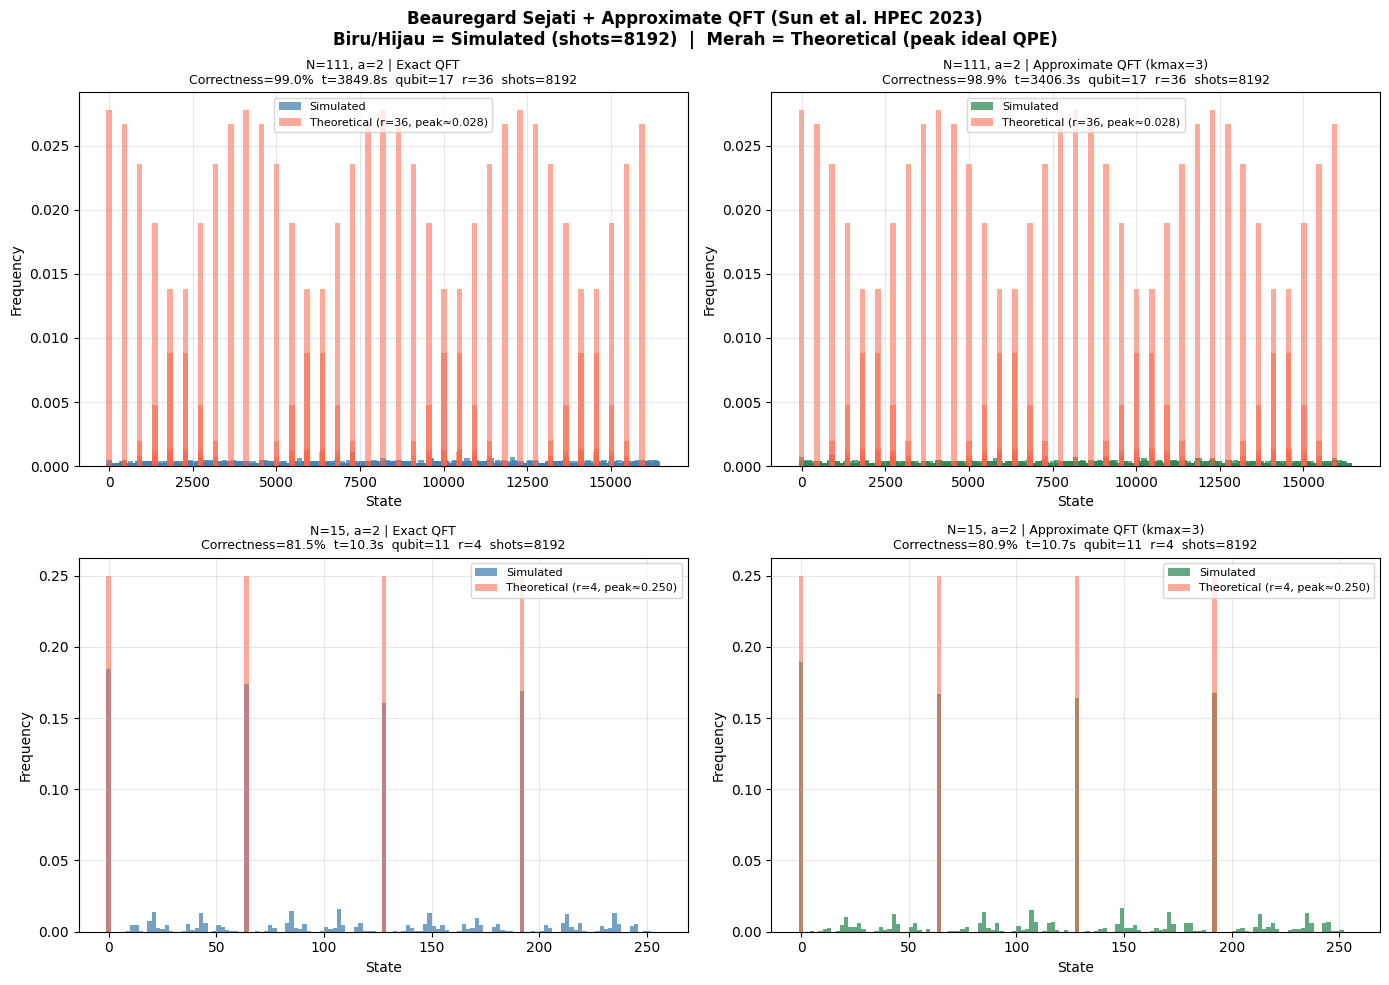

Saved: beauregard_approx_combined.png

Ringkasan dari cache:
  N=111, a=2: r=36, shots=8192
    Exact  → Correctness=99.0%
    Approx → Correctness=98.9%
  N=15, a=2: r=4, shots=8192
    Exact  → Correctness=81.5%
    Approx → Correctness=80.9%


In [20]:
# ── CELL C: Load Cache + Plot ─────────────────────────────────────────────────
# Load spectrum_cache.json dan plot langsung — tidak ada simulasi ulang.
# Pastikan Cell B sudah pernah dijalankan sebelumnya.

import os, json as _json
import numpy as np
import matplotlib.pyplot as plt

CACHE_FILE = 'spectrum_cache.json'

if not os.path.exists(CACHE_FILE):
    print(f'Cache tidak ditemukan: {CACHE_FILE}')
    print('Jalankan Cell B terlebih dahulu.')
else:
    with open(CACHE_FILE, 'r') as f:
        cache = _json.load(f)

    configs = [(111, 2), (15, 2)]
    fig, axes = plt.subplots(len(configs), 2, figsize=(14, 5 * len(configs)))
    if len(configs) == 1:
        axes = [axes]

    fig.suptitle(
        'Beauregard Sejati + Approximate QFT (Sun et al. HPEC 2023)\n'
        'Biru/Hijau = Simulated (shots=8192)  |  Merah = Theoretical (peak ideal QPE)',
        fontsize=12, fontweight='bold'
    )

    for row, (N, a) in enumerate(configs):
        key_N  = f'N{N}_a{a}'
        entry  = cache[key_N]
        t_val  = entry['t_val']
        Q      = entry['Q']
        kmax   = entry['kmax']
        r      = entry['r']
        bw     = max(2, Q // 100)

        theo   = np.array(entry['theo_probs'])

        for col, (mode, label, color) in enumerate([
            ('exact',  'Exact QFT',                  'steelblue'),
            ('approx', f'Approximate QFT (kmax={kmax})', 'seagreen'),
        ]):
            data    = entry[mode]
            prob_sv = np.array(data['prob'])
            corr    = data['corr']
            shots   = data['shots']
            elapsed = data['elapsed']

            ax = axes[row][col]

            ax.bar(np.arange(Q), prob_sv,
                   width=bw, color=color, alpha=0.75, label='Simulated')
            ax.bar(np.arange(Q), theo,
                   width=bw, color='tomato', alpha=0.55,
                   label=f'Theoretical (r={r}, peak≈{1/r:.3f})')

            ax.set_title(
                f'N={N}, a={a} | {label}\n'
                f'Correctness={corr:.1f}%  t={elapsed:.1f}s  qubit={2*ceil(log2(N+1))+3}  r={r}  shots={shots}',
                fontsize=9
            )
            ax.set_xlabel('State')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('beauregard_approx_combined.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: beauregard_approx_combined.png')
    print()
    print('Ringkasan dari cache:')
    for N, a in configs:
        key_N = f'N{N}_a{a}'
        e = cache[key_N]
        print(f'  N={N}, a={a}: r={e["r"]}, shots={e["exact"]["shots"]}')
        print(f'    Exact  → Correctness={e["exact"]["corr"]:.1f}%')
        print(f'    Approx → Correctness={e["approx"]["corr"]:.1f}%')


## 9. Tabel Perbandingan Multi-N

**Speedup diukur dari jumlah CP gate pada bagian QFT** — bukan total circuit depth.

**Kenapa bukan circuit depth?**
- Depth total didominasi oleh `c_Ua` (Beauregard modular mult), yang sama persis untuk exact maupun approx
- Gate P dari classical feedforward terlalu sedikit dibanding ribuan gate `c_Ua` → depth tidak berubah
- Paper Sun et al. mengukur speedup dari **jumlah operasi QFT**: O(L²) → O(L·logL)

```
Speedup_QFT = CP_gates_exact / CP_gates_approx
            = [t(t-1)/2]  /  [Σ min(i, kmax) for i in range(t)]
```

Ini langsung mencerminkan reduksi gate yang diusulkan Beauregard dan diimplementasi jurnal.


In [15]:
# ─── Konfigurasi ────────────────────────────────────────────────────────────
TEST_CASES  = [(15, 2), (111, 2)]
SHOTS_TABLE = 256

print('=' * 78)
print('  TABEL PERBANDINGAN — BEAUREGARD SEJATI 2L+3 + SEMI-CLASSICAL QPE')
print('  Speedup = CP_exact / CP_approx  (reduksi gate QFT, sesuai paper)')
print('=' * 78)
print(f'  {"N":>5} {"a":>3} {"L":>3} {"t":>4} {"kmax":>5} {"Qubit":>6}'
      f'  {"CP-Exact":>9} {"CP-Approx":>10} {"Red%":>6}'
      f'  {"CE%":>6} {"CA%":>6} {"RD%":>6} {"Spdup(QFT)":>11}')
print('  ' + '-' * 78)

all_results = []

for N, a in TEST_CASES:
    L     = ceil(log2(N + 1))
    t_val = 2 * L
    kmax  = compute_kmax(t_val)

    # CP gate count (QFT part)
    cp_exact  = t_val * (t_val - 1) // 2
    cp_approx = sum(min(i, kmax) for i in range(t_val))
    cp_red    = (1 - cp_approx / cp_exact) * 100 if cp_exact > 0 else 0

    # Speedup QFT = CP gate ratio (ini yang dimaksud paper)
    speedup_qft = cp_exact / cp_approx if cp_approx > 0 else 0

    # Jalankan simulasi untuk correctness
    print(f'  Simulating N={N}...', end=' ', flush=True)
    _, CE, _, _, _ = run_beauregard_approx(
        N, a, shots=SHOTS_TABLE, use_approximate=False)
    _, CA, _, _, _ = run_beauregard_approx(
        N, a, shots=SHOTS_TABLE, use_approximate=True)
    print('done')

    rel = abs(CE - CA) / CE * 100 if CE > 0 else 0

    print(f'  {N:>5} {a:>3} {L:>3} {t_val:>4} {kmax:>5} {2*L+3:>6}'
          f'  {cp_exact:>9} {cp_approx:>10} {cp_red:>5.1f}%'
          f'  {CE:>6.1f} {CA:>6.1f} {rel:>6.1f} {speedup_qft:>11.2f}x')

    all_results.append({
        'N': N, 'a': a, 'kmax': kmax,
        'CE': CE, 'CA': CA, 'rel': rel,
        'speedup': speedup_qft,
        'cp_exact': cp_exact, 'cp_approx': cp_approx, 'cp_red': cp_red
    })

print('=' * 78)
print()
print('  Keterangan:')
print('  CP-Exact   = t(t-1)/2           [O(L²)]')
print('  CP-Approx  = Σ min(i,kmax)      [O(L·logL)]')
print('  Red%       = persentase reduksi CP gate')
print('  CE%/CA%    = Correctness Exact/Approx')
print('  RD%        = |CE-CA|/CE × 100%')
print('  Spdup(QFT) = CP_exact/CP_approx  ← speedup sejati dari approximate QFT')
print('  Qubit      = 2L+3 ✓ (Beauregard sejati)')


  TABEL PERBANDINGAN — BEAUREGARD SEJATI 2L+3 + SEMI-CLASSICAL QPE
  Speedup = CP_exact / CP_approx  (reduksi gate QFT, sesuai paper)
      N   a   L    t  kmax  Qubit   CP-Exact  CP-Approx   Red%     CE%    CA%    RD%  Spdup(QFT)
  ------------------------------------------------------------------------------
  Simulating N=15... done
     15   2   4    8     3     11         28         18  35.7%    86.7   85.9    0.9        1.56x
  Simulating N=111... done
    111   2   7   14     3     17         91         36  60.4%    97.7   99.2    1.6        2.53x

  Keterangan:
  CP-Exact   = t(t-1)/2           [O(L²)]
  CP-Approx  = Σ min(i,kmax)      [O(L·logL)]
  Red%       = persentase reduksi CP gate
  CE%/CA%    = Correctness Exact/Approx
  RD%        = |CE-CA|/CE × 100%
  Spdup(QFT) = CP_exact/CP_approx  ← speedup sejati dari approximate QFT
  Qubit      = 2L+3 ✓ (Beauregard sejati)


## 10. Analisis Gate Count — Beauregard vs Matrix Unitary

In [16]:
def count_cp_gates_approx(t, kmax):
    """Hitung gate CP dalam approximate IQFT sesuai Listing 1 jurnal."""
    return sum(min(i, kmax) for i in range(t))

def count_cp_gates_exact(t):
    """Hitung gate CP dalam exact IQFT."""
    return t * (t - 1) // 2

print(f'{"L":>4} {"t":>4} {"kmax":>6} {"CP-Exact":>10} {"CP-Approx":>11} {"Reduksi%":>10}')
print('-' * 52)
for L in [2, 3, 4, 5, 6, 7]:
    t    = 2 * L
    kmax = compute_kmax(t)
    cp_e = count_cp_gates_exact(t)
    cp_a = count_cp_gates_approx(t, kmax)
    red  = (1 - cp_a / cp_e) * 100 if cp_e > 0 else 0
    print(f'{L:>4} {t:>4} {kmax:>6} {cp_e:>10} {cp_a:>11} {red:>9.1f}%')

   L    t   kmax   CP-Exact   CP-Approx   Reduksi%
----------------------------------------------------
   2    4      2          6           5      16.7%
   3    6      2         15           9      40.0%
   4    8      3         28          18      35.7%
   5   10      3         45          24      46.7%
   6   12      3         66          30      54.5%
   7   14      3         91          36      60.4%


## 11. Visualisasi Ringkasan (Speedup = CP Gate Ratio)


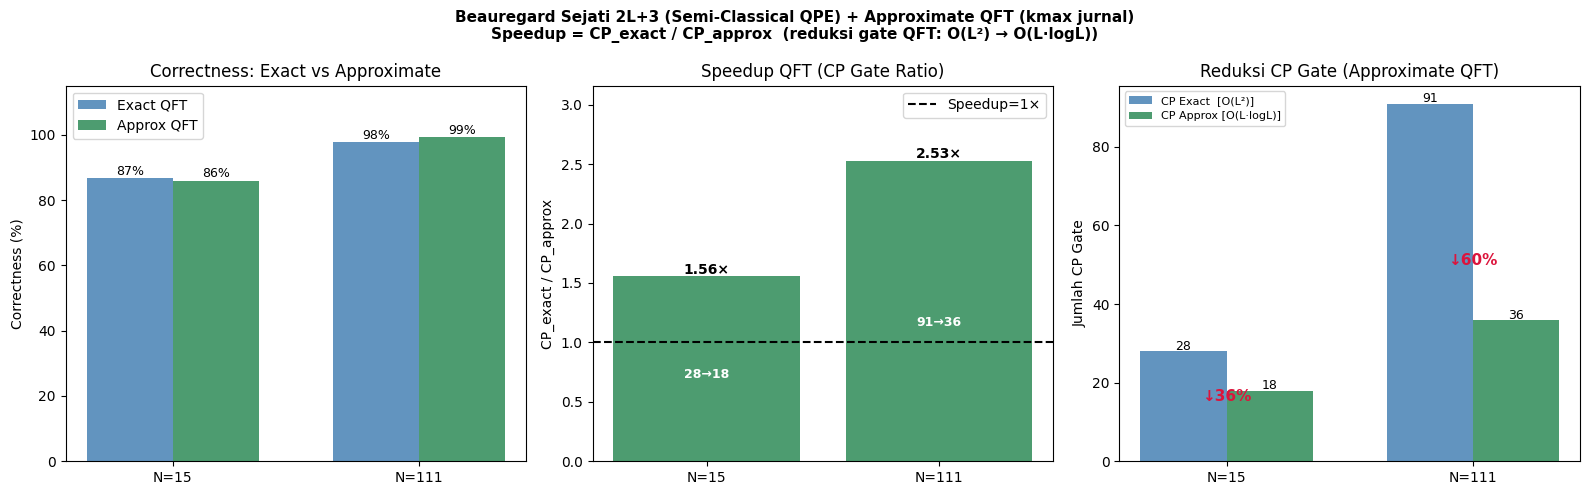

Saved: beauregard_approx_summary_corrected.png


In [17]:
if all_results:
    labels = [f"N={r['N']}" for r in all_results]
    x = np.arange(len(labels))
    w = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        'Beauregard Sejati 2L+3 (Semi-Classical QPE) + Approximate QFT (kmax jurnal)\n'
        'Speedup = CP_exact / CP_approx  (reduksi gate QFT: O(L²) → O(L·logL))',
        fontweight='bold', fontsize=11
    )

    # ── Plot 1: Correctness ────────────────────────────────────────────────
    axes[0].bar(x - w/2, [r['CE'] for r in all_results], w,
                label='Exact QFT',  color='steelblue', alpha=0.85)
    axes[0].bar(x + w/2, [r['CA'] for r in all_results], w,
                label='Approx QFT', color='seagreen',  alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('Correctness (%)')
    axes[0].set_title('Correctness: Exact vs Approximate')
    axes[0].set_ylim(0, 115)
    axes[0].legend()
    for i, r in enumerate(all_results):
        axes[0].text(i - w/2, r['CE'] + 1, f"{r['CE']:.0f}%", ha='center', fontsize=9)
        axes[0].text(i + w/2, r['CA'] + 1, f"{r['CA']:.0f}%", ha='center', fontsize=9)

    # ── Plot 2: Speedup (CP gate ratio) ───────────────────────────────────
    speedup_vals = [r['speedup'] for r in all_results]
    bar_colors   = ['seagreen' if s >= 1 else 'tomato' for s in speedup_vals]
    bars = axes[1].bar(labels, speedup_vals, color=bar_colors, alpha=0.85)
    axes[1].axhline(1.0, color='black', ls='--', lw=1.5, label='Speedup=1×')
    axes[1].set_ylabel('CP_exact / CP_approx')
    axes[1].set_title('Speedup QFT (CP Gate Ratio)')
    axes[1].set_ylim(0, max(speedup_vals) * 1.25)
    axes[1].legend()
    for bar, r in zip(bars, all_results):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{r['speedup']:.2f}×", ha='center', fontsize=10, fontweight='bold')
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 0.45,
                     f"{r['cp_exact']}→{r['cp_approx']}",
                     ha='center', fontsize=9, color='white', fontweight='bold')

    # ── Plot 3: CP Gate Reduction ──────────────────────────────────────────
    axes[2].bar(x - w/2, [r['cp_exact']  for r in all_results], w,
                label='CP Exact  [O(L²)]',      color='steelblue', alpha=0.85)
    axes[2].bar(x + w/2, [r['cp_approx'] for r in all_results], w,
                label='CP Approx [O(L·logL)]',  color='seagreen',  alpha=0.85)
    axes[2].set_xticks(x); axes[2].set_xticklabels(labels)
    axes[2].set_ylabel('Jumlah CP Gate')
    axes[2].set_title('Reduksi CP Gate (Approximate QFT)')
    axes[2].legend(fontsize=8)
    for i, r in enumerate(all_results):
        axes[2].text(i - w/2, r['cp_exact']  + 0.3, str(r['cp_exact']),
                     ha='center', fontsize=9)
        axes[2].text(i + w/2, r['cp_approx'] + 0.3, str(r['cp_approx']),
                     ha='center', fontsize=9)
        axes[2].text(i,
                     max(r['cp_exact'], r['cp_approx']) * 0.55,
                     f"↓{r['cp_red']:.0f}%",
                     ha='center', fontsize=11, color='crimson', fontweight='bold')

    plt.tight_layout()
    plt.savefig('beauregard_approx_summary_corrected.png', dpi=150)
    plt.show()
    print('Saved: beauregard_approx_summary_corrected.png')


In [21]:
# ─── Tampilkan nilai p dan q dari kedua mode ─────────────────────────────────

def extract_factors_verbose(counts, a, t, N, label=''):
    """
    Ekstrak dan tampilkan faktor p dan q dari hasil pengukuran.
    Mengembalikan list hasil berhasil temukan faktor.
    """
    results = []
    for b, cnt in counts.items():
        measured = int(b.replace(' ', ''), 2)
        r_list   = cf_period(measured, t, N)
        f1, f2   = get_factors(a, r_list, N)
        if f1 is not None:
            results.append({'measured': measured, 'count': cnt, 'p': f1, 'q': f2})
    return results


def print_pq_table(results, shots, label):
    print(f'\n  [{label}]')
    if not results:
        print('    Tidak ada faktor (p, q) yang berhasil ditemukan.')
        return
    # Kumpulkan pasangan unik (p, q) dengan total shot-nya
    pq_map = {}
    for r in results:
        key = (r['p'], r['q'])
        pq_map[key] = pq_map.get(key, 0) + r['count']
    print(f'  {"p":>6}  {"q":>6}  {"Count":>8}  {"Prob":>8}')
    print('  ' + '-' * 36)
    for (p, q), cnt in sorted(pq_map.items(), key=lambda x: -x[1]):
        print(f'  {p:>6}  {q:>6}  {cnt:>8}  {cnt/shots*100:>7.2f}%')


print('=' * 60)
print('  HASIL FAKTORISASI — NILAI p dan q dari Kedua Mode')
print('=' * 60)

N_test, a_test = 15, 2
N_test2, a_test2 = 111, 2
shots_test, shots_test2 = 1024, 1024

counts_e, CE, timing_e, qc_e, t_e = run_beauregard_approx(
    N_test, a_test, shots=shots_test, use_approximate=False, verbose=True
)
counts_a, CA, timing_a, qc_a, t_a = run_beauregard_approx(
    N_test, a_test, shots=shots_test, use_approximate=True, verbose=True
)
counts_e2, CE2, timing_e2, qc_e2, t_e2 = run_beauregard_approx(
    N_test2, a_test2, shots=shots_test2, use_approximate=False, verbose=True
)
counts_a2, CA2, timing_a2, qc_a2, t_a2 = run_beauregard_approx(
    N_test2, a_test2, shots=shots_test2, use_approximate=True, verbose=True
)
kmax_val = compute_kmax(t_a2)
kmax_val2 = compute_kmax(t_e2)

# ── N=15, a=2 ────────────────────────────────────────────────────────────────
print(f'\n N={N_test}, a={a_test}')
print('  ' + '-' * 58)

ef_e = extract_factors_verbose(counts_e, a_test, t_e, N_test)
print_pq_table(ef_e, shots_test, 'Exact QFT')

ef_a = extract_factors_verbose(counts_a, a_test, t_a, N_test)
print_pq_table(ef_a, shots_test, f'Approximate QFT (kmax={kmax_val})')

# ── N=111, a=2 ───────────────────────────────────────────────────────────────
print(f'\n N={N_test2}, a={a_test2}')
print('  ' + '-' * 58)

ef_e2 = extract_factors_verbose(counts_e2, a_test2, t_e2, N_test2)
print_pq_table(ef_e2, shots_test2, 'Exact QFT')

ef_a2 = extract_factors_verbose(counts_a2, a_test2, t_a2, N_test2)
print_pq_table(ef_a2, shots_test2, f'Approximate QFT (kmax={kmax_val2})')

print()
print('  Keterangan:')
print('  p, q  = pasangan faktor dari N   (p × q = N)')
print('  Count = jumlah shot yang menghasilkan faktor tersebut')
print('  Prob  = persentase shot yang menghasilkan faktor tersebut')


  HASIL FAKTORISASI — NILAI p dan q dari Kedua Mode
  N=15, a=2, L=4, t=8, kmax=8
  Total qubit: 11 = 1(ctrl) + 4(x) + 5(b) + 1(anc)
  Build time  : 0.14s
  Circuit size: 7132 gates
  Circuit depth:3792
  Qubits      : 11 (target: 11) ✓
  N=15, a=2, L=4, t=8, kmax=3
  Total qubit: 11 = 1(ctrl) + 4(x) + 5(b) + 1(anc)
  Build time  : 0.12s
  Circuit size: 7122 gates
  Circuit depth:3792
  Qubits      : 11 (target: 11) ✓
  N=111, a=2, L=7, t=14, kmax=14
  Total qubit: 17 = 1(ctrl) + 7(x) + 8(b) + 1(anc)
  Build time  : 0.83s
  Circuit size: 51122 gates
  Circuit depth:22532
  Qubits      : 17 (target: 17) ✓
  N=111, a=2, L=7, t=14, kmax=3
  Total qubit: 17 = 1(ctrl) + 7(x) + 8(b) + 1(anc)
  Build time  : 0.84s
  Circuit size: 51067 gates
  Circuit depth:22532
  Qubits      : 17 (target: 17) ✓

 N=15, a=2
  ----------------------------------------------------------

  [Exact QFT]
       p       q     Count      Prob
  ------------------------------------
       3       5       796    77.73